# SETUP

In [1]:
import sys
sys.path.append("..")

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import random
from torch.utils.data import DataLoader

from data_utils.scan_helpers import (
    download_scan_simple_split,
    download_scan_add_prim_split,
    load_scan_split,
    build_vocab,
    PAD,
    BOS,
    EOS,
)

from evaluation.scan_evaluation import (
    greedy_decode,
    sequence_accuracy,
    evaluate_sequence_accuracy,
    ordered_sequence_token_accuracy,   
    evaluate_ordered_token_accuracy,
    evaluate_teacher_forced_ordered_token_accuracy,
    teacher_forced_ordered_sequence_accuracy,
)

from training.train import (
    train_model,
)

from result_utils.save_results import (
    save_experiment_results,
    load_experiment_results,
)

from result_utils.plot_results import (
    exp3_plot_token_accuracy,
    exp3_plot_sequence_accuracy,
    exp3_part1_plot_token_accuracy,
    exp3_part1_plot_sequence_accuracy,
    exp1_plot_sequence_accuracy,
)

from data_utils.scan_dataset import ScanDataset
from data_utils.scan_dataloader import collate_scan_batch

from models.transformer import Transformer

In [3]:
SEED_BASE = 42

In [4]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'{device} - {device_name}')

PyTorch version: 2.5.1
CUDA available: True
cuda - NVIDIA GeForce GTX 1050 Ti with Max-Q Design


In [5]:
import time
from contextlib import contextmanager

@contextmanager
def stopwatch(name: str):
    start = time.perf_counter()
    try:
        yield
    finally:
        elapsed = time.perf_counter() - start
        print(f"[{name}] Elapsed time: {elapsed:.2f} seconds")

## Load SCAN & Create Vocabulary

In [6]:
scan_dir = download_scan_simple_split()

train_inputs, train_outputs = load_scan_split(
    f"{scan_dir}/tasks_train_simple.txt"
)
test_inputs, test_outputs = load_scan_split(
    f"{scan_dir}/tasks_test_simple.txt"
)

print(f"Train samples: {len(train_inputs)}")
print(f"Test samples:  {len(test_inputs)}")

Train samples: 16728
Test samples:  4182


In [7]:
source_vocab = build_vocab(train_inputs)
target_vocab = build_vocab(train_outputs)

print("Source vocab size:", len(source_vocab))
print("Target vocab size:", len(target_vocab))

Source vocab size: 16
Target vocab size: 9


## Experiment 1 - Seq Accuracy in regards to % of commands used

In [ ]:
percentages = [1, 2, 4, 8, 16, 32, 64]

dataset_pairs = []

for percentage_cmds_used in percentages:
    train_path = f"data/simple_split/size_variations/tasks_train_simple_p{percentage_cmds_used}.txt"
    test_path  = f"data/simple_split/size_variations/tasks_test_simple_p{percentage_cmds_used}.txt"

    dataset_pairs.append((percentage_cmds_used, train_path, test_path))

In [10]:
results = {}
run_accuracies = {}
NUM_RUNS = 5

print(f"Starting Experiment 1, training and testing 'sequence' accuary in regards to % of commands used for training.")
print(f"For each dataset, training and testing will be done 5 times with different seeds, to account for variability in random initialization.")

for percentage_cmds_used, train_path, test_path in dataset_pairs:
    with stopwatch(f"Percentage of commands used {percentage_cmds_used}"):
        print(f"Training on: {percentage_cmds_used}% of commands")

        train_inputs, train_outputs = load_scan_split(train_path)
        test_inputs, test_outputs   = load_scan_split(test_path)
        source_vocab = build_vocab(train_inputs)
        target_vocab = build_vocab(train_outputs)

        train_dataset = ScanDataset(
            train_inputs, train_outputs, source_vocab, target_vocab
        )
        test_dataset = ScanDataset(
            test_inputs, test_outputs, source_vocab, target_vocab
        )
        train_loader = DataLoader(
            train_dataset,
            batch_size=64,
            shuffle=True,
            collate_fn=collate_scan_batch,
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=64,
            shuffle=False,
            collate_fn=collate_scan_batch,
        )

        run_accuracies = []

        for run_idx in range(1, NUM_RUNS + 1):
            print(f"Run {run_idx}/{NUM_RUNS}")

            p1_run_seed = SEED_BASE + run_idx
            torch.manual_seed(p1_run_seed)
            random.seed(p1_run_seed)
            np.random.seed(p1_run_seed)

            model = Transformer(
                source_vocab_size=len(source_vocab),
                target_vocab_size=len(target_vocab),
                source_padding_index=PAD,
                target_padding_index=PAD,
                emb_dim=128,
                num_layers=1,
                num_heads=8,
                forward_dim=512,
                dropout=0.05,
                max_sequence_length=512,
            ).to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=7e-4)
            criterion = nn.CrossEntropyLoss(ignore_index=PAD)

            train_model(
                model=model,
                train_loader=train_loader,
                optimizer=optimizer,
                criterion=criterion,
                device=device,
                grad_clip=1.0,
                max_samples=100_000,
            )

            final_seq_acc = evaluate_ordered_token_accuracy(
                model, test_loader, device
            )

            print(f"Final sequence accuracy: {final_seq_acc * 100:.2f}%")

            run_accuracies.append(final_seq_acc)

        mean_acc = float(np.mean(run_accuracies))
        std_acc  = float(np.std(run_accuracies))

        results[percentage_cmds_used] = {
            "mean": mean_acc,
            "std": std_acc,
            "runs": run_accuracies,
        }

        print(
            f"\nResult for {percentage_cmds_used}%: "
            f"{mean_acc*100:.2f}% ± {std_acc*100:.2f}%"
        )

Starting Experiment 1, training and testing 'sequence' accuary in regards to % of commands used for training.
For each dataset, training and testing will be done 5 times with different seeds, to account for variability in random initialization.
Training on: 1% of commands
Run 1/5


Training samples: 100030it [00:34, 2921.32it/s]                           


Training complete.
Final sequence accuracy: 60.50%
Run 2/5


Training samples: 100030it [00:36, 2737.60it/s]                           


Training complete.
Final sequence accuracy: 65.16%
Run 3/5


...

Training complete.
Final sequence accuracy: 96.39%
Run 4/5


Training samples: 100010it [00:37, 2670.21it/s]                           


Training complete.
Final sequence accuracy: 97.29%
Run 5/5


Training samples: 100010it [00:35, 2845.13it/s]                           


Training complete.
Final sequence accuracy: 97.10%

Result for 64%: 96.98% ± 0.32%
[Percentage of commands used 64] Elapsed time: 378.45 seconds


In [11]:
save_experiment_results(
    results=results,
    filename="experiment_1_full",
    experiment_nr=1,
    description="Experiment 1: Sequence accuary in regards to % of commands used for training",
)

Results saved to results/experiment_1\experiment_1_full.181220250025.json


In [12]:
import matplotlib.pyplot as plt

def exp1_plot_sequence_accuracy(results):
    """
    Plot sequence-level accuracy vs percentage of commands used for training.
    """
    percentages = sorted(results.keys())
    mean_accuracies = [results[p]["mean"] * 100 for p in percentages]

    plt.figure(figsize=(7, 5))
    plt.bar(range(len(percentages)), mean_accuracies)
    plt.xticks(range(len(percentages)), percentages)
    plt.xlabel("Percentage of Commands Used for Training")
    plt.ylabel("Sequence Accuracy (%)")
    plt.title("Experiment 1: Sequence-Level Accuracy vs Training Coverage")
    plt.ylim(0, 100)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

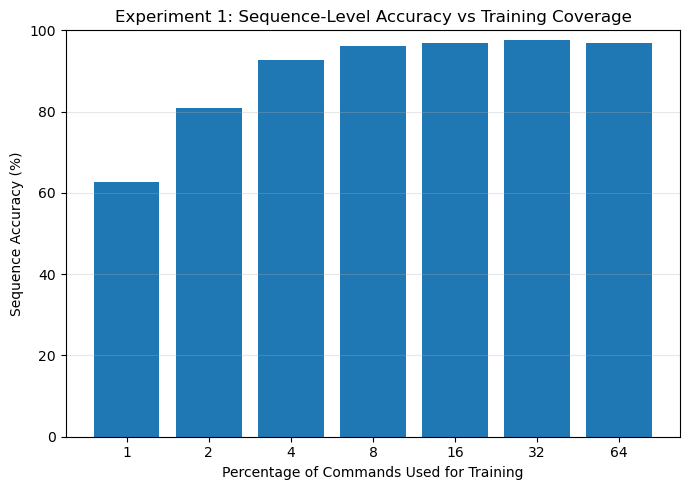

In [13]:
exp1_plot_sequence_accuracy(results)